Shon Kucherenko

In [94]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def draw_unit_circle_and_angles(degree_angles: list[float], labels: list[str]):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])
    ax.grid(True, linestyle='--')

    unit_circle = Circle((0, 0), 1, color='blue', fill=False, linewidth=2)
    ax.add_patch(unit_circle)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    
    for angle, label in zip(degree_angles, labels):
        angle_rad = math.radians(angle)
        x = math.cos(angle_rad)
        y = math.sin(angle_rad)
        ax.plot(x, y, 'ro')
        
        ax.plot([0, x], [0, y], 'r-', linewidth=1.5)
        
        text_radius = 1.15
        text_x = text_radius * x
        text_y = text_radius * y
        ax.text(text_x, text_y, f'{label}', color='red', ha='center', va='center')

    plt.show()


In [96]:
import matplotlib.pyplot as plt
import numpy as np

def draw_cartesian(points: list[tuple[float, float]], labels: list[str]):
    x_points = [x[0] for x in points]
    y_points = [x[1] for x in points]
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    ax.scatter(x_points, y_points, color='red', marker='o', s=100, label="Points")
    
    for i, label in enumerate(labels):
        plt.annotate(label, (x_points[i], y_points[i]), xytext=(0, 7), textcoords="offset points")
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    limit = abs(max(x_points + y_points, key=abs)) + 1
    
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    
    ax.set_xticks(np.arange(-limit, limit))
    ax.set_yticks(np.arange(-limit, limit))
    
    ax.legend()
    plt.show()

def draw_polar(points: list[tuple[float, float]], labels: list[str]):
    x_points = [points[i][0] * math.cos(points[i][1]) for i in range(len(points))]
    y_points = [points[i][0] * math.sin(points[i][1]) for i in range(len(points))]
    
    fig, ax = plt.subplots(figsize=(12, 12))
    
    ax.scatter(x_points, y_points, color='red', marker='o', s=100, label="Points")
    
    for i, label in enumerate(labels):
        plt.annotate(label, (x_points[i], y_points[i]), xytext=(0, 7), textcoords="offset points")
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    limit = abs(max(x_points + y_points, key=abs)) + 1
    
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    
    ax.set_xticks(np.arange(-limit, limit))
    ax.set_yticks(np.arange(-limit, limit))
    
    ax.legend()
    plt.show()


# Task 1

Convert degrees to radians and radians to degrees and draw them on the unit circle:

Radian 0.3 -> 17.188733853924695
Radian 1.0 -> 57.29577951308232
Radian 1.3 -> 74.48451336700703
Radian 7.4 -> 423.98876839680923
---
Degree 22 -> 0.3839724354387525
Degree 288 -> 5.026548245743669
Degree 15 -> 0.2617993877991494
Degree 99 -> 1.7278759594743864


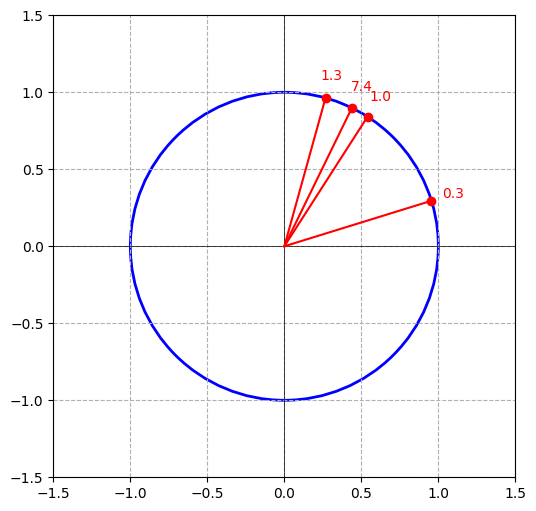

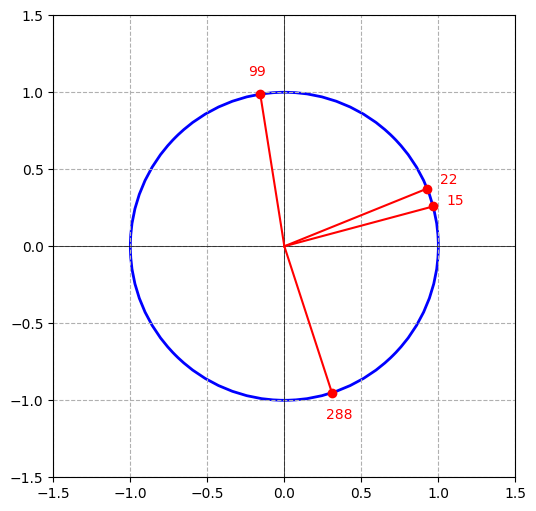

In [97]:
import math

def deg_to_rad(deg: float) -> float:
    return deg * math.pi / 180

def rag_to_deg(rad: float) -> float:
    return rad / math.pi * 180

source_radians = [0.3, 1.0, 1.3, 7.4]
source_degrees = [22, 288, 15, 99]

result_degrees = [rag_to_deg(x) for x in source_radians]
result_radians = [deg_to_rad(x) for x in source_degrees]

for i in range(len(result_radians)):
    print(f"Radian {source_radians[i]} -> {result_degrees[i]}")

print("---")

for i in range(len(result_radians)):
    print(f"Degree {source_degrees[i]} -> {result_radians[i]}")
    
draw_unit_circle_and_angles(result_degrees, source_radians)
draw_unit_circle_and_angles([rag_to_deg(x) for x in result_radians], source_degrees)
    

# Task 2

Translate from polar to cartesian coordinate systems and draw them on plot:

Polar (5.0, 1.2) r,θ -> Cartesian (1.811788772383368, 4.660195429836131) x,y
Polar (0.3, 1.0) r,θ -> Cartesian (0.1620906917604419, 0.25244129544236893) x,y
Polar (1.0, 3.3) r,θ -> Cartesian (-0.9874797699088649, -0.1577456941432482) x,y
Polar (0.2, 2.5) r,θ -> Cartesian (-0.16022872310938674, 0.11969442882079129) x,y
Polar (8.2, 5.3) r,θ -> Cartesian (4.545869556669118, -6.8245930262359895) x,y
Polar (1.2, 3.2) r,θ -> Cartesian (-1.1979537309537036, -0.0700489721130961) x,y
Polar (2.9, 3.3) r,θ -> Cartesian (-2.863691332735708, -0.4574625130154198) x,y
Polar (1.7, 2.1) r,θ -> Cartesian (-0.8582383778197579, 1.4674559233030853) x,y


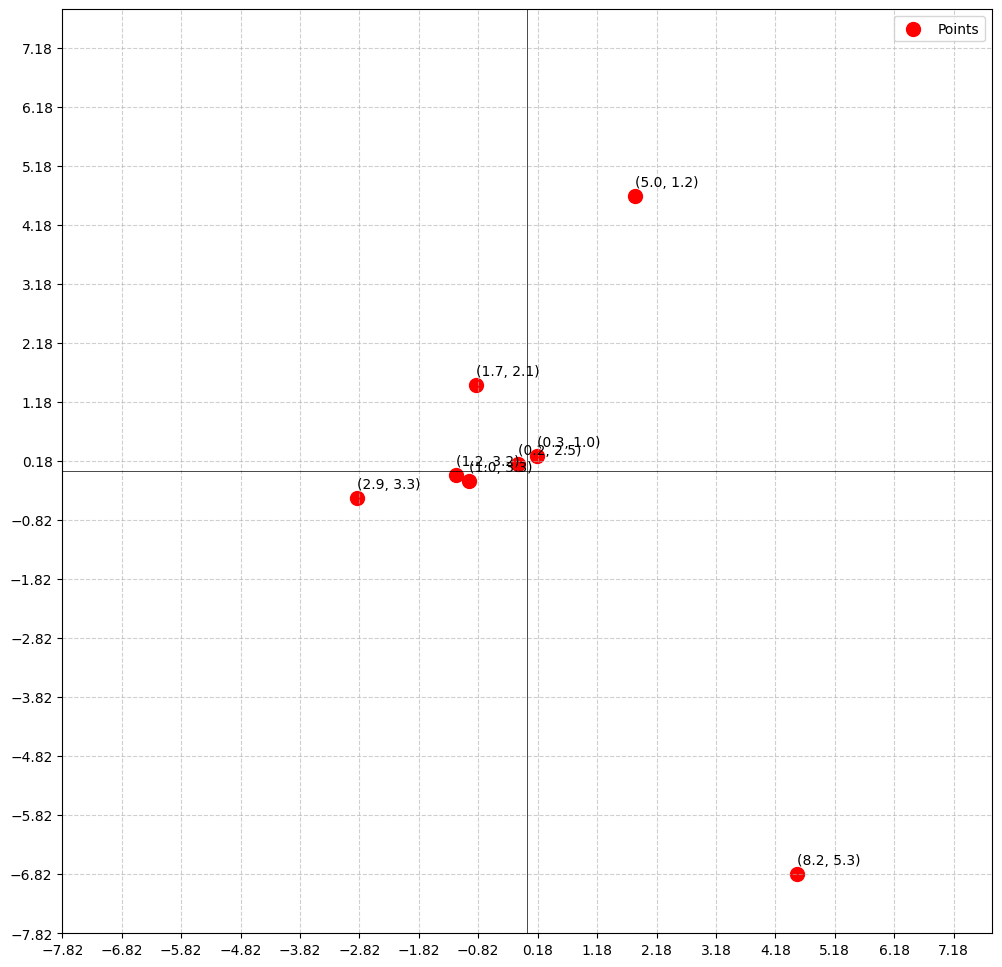

In [98]:
def polar_to_cartesian(polar: tuple[float, float]) -> tuple[float, float]:
    radius = polar[0]
    angle = polar[1]
    
    x = math.cos(angle) * radius
    y = math.sin(angle) * radius
    
    return x, y

polar_coordinates = [(5.0, 1.2), (0.3, 1.0), (1.0, 3.3), (0.2, 2.5), (8.2, 5.3), (1.2, 3.2), (2.9, 3.3), (1.7, 2.1)]

cartesian_coordinates = [polar_to_cartesian(x) for x in polar_coordinates]

for i in range(len(cartesian_coordinates)):
    print(f"Polar {polar_coordinates[i]} r,θ -> Cartesian {cartesian_coordinates[i]} x,y")
    
draw_cartesian(cartesian_coordinates, [f"{x}" for x in polar_coordinates])


# Task 3

Translate from cartesian to polar coordinate systems and draw them on plot:

Cartesian (0.1, 0.4) x,y -> Polar (0.4123105625617661, 1.3258176636680326) r,θ
Cartesian (1.2, 0.1) x,y -> Polar (1.2041594578792296, 0.08314123188844123) r,θ
Cartesian (0.1, 1.3) x,y -> Polar (1.3038404810405297, 1.4940244355251187) r,θ
Cartesian (-0.1, 1.3) x,y -> Polar (1.3038404810405297, 1.6475682180646747) r,θ
Cartesian (-2.0, 0.1) x,y -> Polar (2.0024984394500787, 3.0916342578678506) r,θ
Cartesian (-1.1, -0.3) x,y -> Polar (1.140175425099138, -2.875340604438868) r,θ
Cartesian (-0.8, 0.8) x,y -> Polar (1.1313708498984762, 2.356194490192345) r,θ
Cartesian (-1.2, 0.3) x,y -> Polar (1.2369316876852983, 2.896613990462929) r,θ


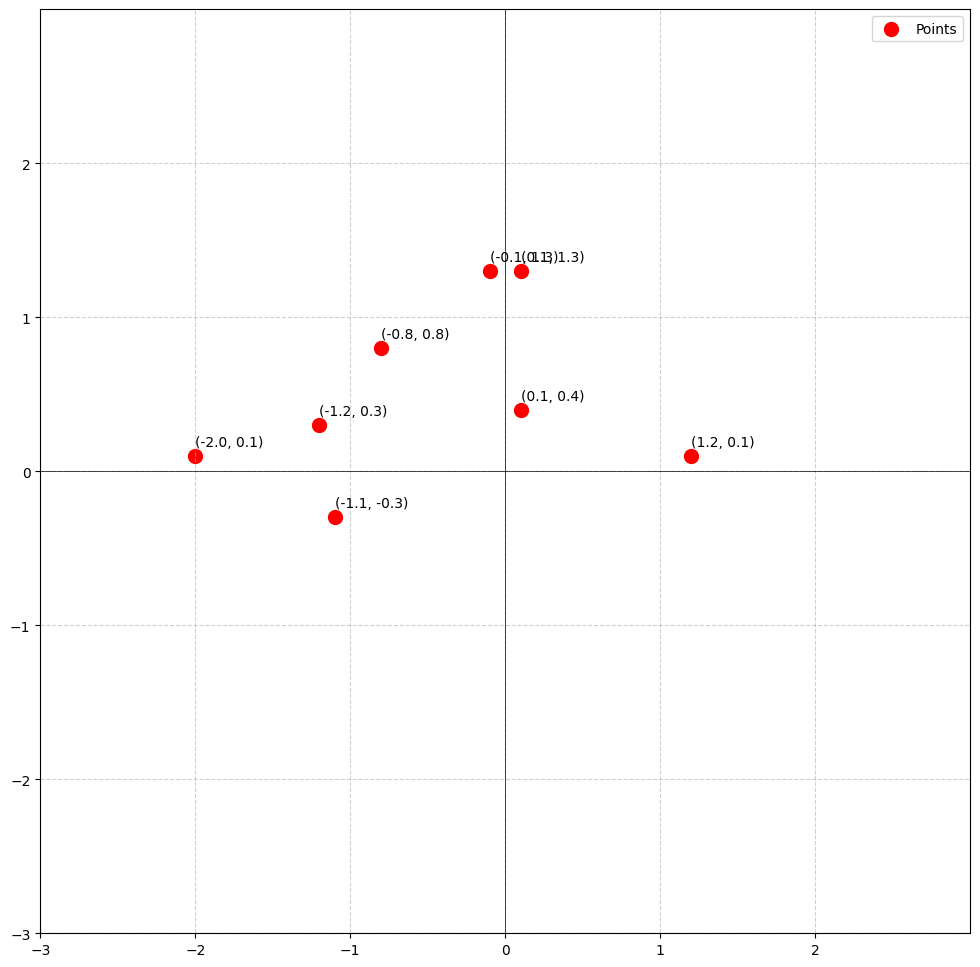

In [99]:
def cartesian_to_polar(cartesian: tuple[float, float]) -> tuple[float, float]:
    x = cartesian[0]
    y = cartesian[1]
    
    radius = math.sqrt(x ** 2 + y ** 2)
    angle = math.atan2(y, x)
    
    return radius, angle

cartesian_coordinates = [(0.1, 0.4), (1.2, 0.1), (0.1, 1.3), (-0.1, 1.3), (-2.0, 0.1), (-1.1, -0.3), (-0.8, 0.8), (-1.2, 0.3)]

polar_coordinates = [cartesian_to_polar(x) for x in cartesian_coordinates]

for i in range(len(cartesian_coordinates)):
    print(f"Cartesian {cartesian_coordinates[i]} x,y -> Polar {polar_coordinates[i]} r,θ")
    
draw_polar(polar_coordinates, [f"{x}" for x in cartesian_coordinates])


# Task 4

Satellites rotate around a planet by circular orbit with a radius of 2 units. Satellite moves with speed of 0.4 units per hour by orbit. Find time by which satellite perform one whole rotation around the planet.

In [100]:
radius = 2
speed = 0.4
full_rotation_radians = 2 * math.pi

# L(x) = r * rads
# speed = radius * rads
rads_per_hour = speed / radius

orbit_hours = full_rotation_radians / rads_per_hour

print(f"{orbit_hours} hours")

31.41592653589793 hours


# Task 5

Satellites rotate around a planet by circular orbit with a radius of 3 units. Satellite moves with speed of 0.3 units per hour by orbit. Assuming satellite initial point named S, and destination point named D, how big is angle between points S and D if:

In [101]:
time = [1.5, 2, 9.2, 63]

radius = 3
speed = 0.3

# L(x) = rad * r
# rad = L(x) / r = speed * duration / r

def angle_from_hour(duration: float):
    return speed * duration / radius

angles = [angle_from_hour(x) for x in time]

for i in range(len(time)):
    print(f"{angles[i] * 180 / math.pi} degrees in {time[i]} hours")


8.594366926962348 degrees in 1.5 hours
11.459155902616464 degrees in 2 hours
52.71211715203574 degrees in 9.2 hours
360.96341093241864 degrees in 63 hours


# Task 6

A player is placed at point with coordinates (+3, +4) and looking in direction of point with coordinates (+11, +1). The player’s vision cone is 40 degrees. Does player see those points:

In [104]:
points = [(10, 0), (11, 4), (12, 1), (10, -1), (5, -2), (2, 4)]

player = (3, 4)
look_at = (11, 1)
degrees = 40

def sees_point(point: tuple[float, float]) -> bool:
    look_direction = (look_at[0] - player[0], look_at[1] - player[1])
    point_direction = (point[0] - player[0], point[1] - player[1])
    
    look_direction_length = math.sqrt(look_direction[0] ** 2 + look_direction[1] ** 2)
    point_direction_length = math.sqrt(point_direction[0] ** 2 + point_direction[1] ** 2)
    
    look_direction = (look_direction[0] / look_direction_length, look_direction[1] / look_direction_length)
    point_direction = (point_direction[0] / point_direction_length, point_direction[1] / point_direction_length)
    
    # Normalized, so dot product equals to cos value
    dot_product = look_direction[0] * point_direction[0] + look_direction[1] * point_direction[1]
    angle = math.acos(dot_product) * 180 / math.pi
    
    return angle < degrees / 2

sees = [sees_point(x) for x in points]

for i in range(len(points)):
    print(f"{points[i]} is{" not" if not sees[i] else ""} seen")

(10, 0) is seen
(11, 4) is not seen
(12, 1) is seen
(10, -1) is seen
(5, -2) is not seen
(2, 4) is not seen
